# Random Forest 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Librerías de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Entrenamiento del Modelo Random Forest 

✅ Dataset cargado correctamente.
Dimensiones: (891, 8)

Datos de Entrenamiento: 712 pasajeros
Datos de Prueba (Examen): 179 pasajeros

⏳ Entrenando el modelo...
✅ ¡Entrenamiento completado!

🎯 PRECISIÓN DEL MODELO: 81.01%

--- Reporte Detallado de Clasificación ---
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       105
           1       0.76      0.80      0.78        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.81      0.81      0.81       179



/tmp/ipykernel_17987/2781505394.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


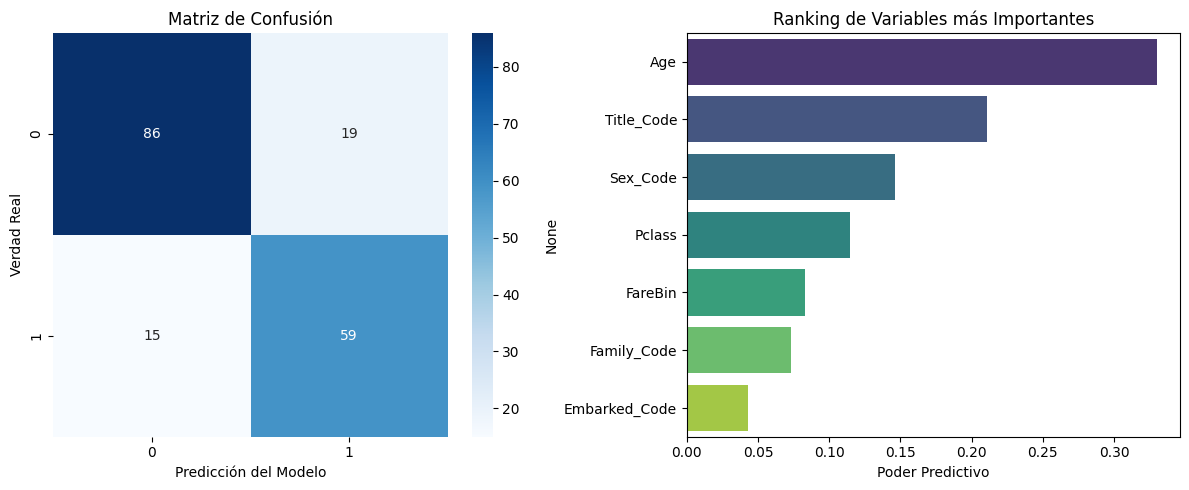

In [7]:
# --- PASO 1: Carga de Datos Limpios ---
try:
    # Cargamos el archivo que guardaste en el paso anterior
    df = pd.read_csv('titanic_train_clean.csv')
    print("✅ Dataset cargado correctamente.")
    print(f"Dimensiones: {df.shape}")
except FileNotFoundError:
    print("❌ Error: No encuentro 'titanic_train_clean.csv'. Asegúrate de haberlo guardado en el paso anterior.")

# --- PASO 2: Separación de Features (X) y Target (y) ---
X = df.drop('Survived', axis=1)  # Las preguntas del examen (Datos)
y = df['Survived']               # Las respuestas correctas (Sobrevivió o no)

# --- PASO 3: División Train / Test ---
# Usamos el 80% para estudiar (Train) y guardamos el 20% para el examen final (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDatos de Entrenamiento: {X_train.shape[0]} pasajeros")
print(f"Datos de Prueba (Examen): {X_test.shape[0]} pasajeros")

# --- PASO 4: Inicialización y Entrenamiento ---
# Creamos el Bosque con 100 árboles de decisión
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("\n⏳ Entrenando el modelo...")
rf_model.fit(X_train, y_train)
print("✅ ¡Entrenamiento completado!")

# --- PASO 5: Predicción y Evaluación ---
# El modelo hace el examen (predice sobre datos que nunca ha visto)
y_pred = rf_model.predict(X_test)

# Calculamos la nota final (Accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 PRECISIÓN DEL MODELO: {acc:.2%}")

print("\n--- Reporte Detallado de Clasificación ---")
print(classification_report(y_test, y_pred))

# --- PASO 6: Visualización de Resultados ---
plt.figure(figsize=(12, 5))

# 6.1 Matriz de Confusión (¿Dónde se equivocó?)
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Verdad Real')
plt.xlabel('Predicción del Modelo')

# 6.2 Importancia de Variables (¿Qué fue lo más importante para decidir?)
plt.subplot(1, 2, 2)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Ranking de Variables más Importantes')
plt.xlabel('Poder Predictivo')

plt.tight_layout()
plt.show()

### Matriz de Confusión

Los errores no son aleatorios, tienen historia:

* **Los "Falsos Esperanzados" (Falsos Positivos - 19 casos):**
* *El Modelo dijo:* "Sobrevive" (1).
* *Realidad:* Murió (0).
* *Perfil probable:* Mujeres de 3ra clase que, por estadística ("Mujeres primero"), debieron salvarse, pero quedaron atrapadas. O niñas de familias grandes (`Large Family`) que el modelo pensó que se salvarían por edad.

* **Los "Muertos Vivientes" (Falsos Negativos - 15 casos):**
* *El Modelo dijo:* "Muere" (0).
* *Realidad:* Sobrevivió (1).
* *Perfil probable:* Hombres (`Mr`) que lograron colarse en un bote, o gente de 1ra clase que el modelo penalizó por alguna razón.

**Conclusión:** Se tiene más "Falsos Positivos" (19) que negativos. El modelo es ligeramente **optimista**.

### El Misterio de la Variable #1: `Age`

Es especial que `Age` haya ganado el primer lugar, superando a `Sex_Code`.

* **¿Por qué?** Se realizo una **imputación inteligente** de la edad basada en el título.
* *El truco:* La variable `Age` ahora contiene dos informaciones: la **biología** (niño/adulto) y el **estatus social** (implícito en el título usado para imputar). Por eso es tan poderosa. El Random Forest la usa para hacer cortes muy finos (ej: "Si edad < 8 vive, si edad > 60 muere").

### El Ranking de Poder

1. **Age:** El discriminador fino.
2. **Title_Code:** El estatus social general.
3. **Sex_Code:** La regla base.
4. **Pclass:** El contexto económico macro.
5. **FareBin:** El poder adquisitivo refinado (aporta menos que Pclass porque están correlacionadas).


## Hiperparametros

Se realizara un **GridSearch**. Esto es poner a la computadora a probar 50 combinaciones diferentes de configuración para encontrar la "receta perfecta".

### Los 3 "Botones" que se va a ajustar

Para el Titanic, vamos a tunear estos tres hiperparámetros críticos del Random Forest:

1. **`n_estimators` (Número de Árboles):**
* *Significado:* ¿Cuántos "jueces" vamos a consultar para decidir si alguien vive?
* *Opciones:* 100, 200, 300.
* *Lógica:* Más árboles suelen dar mayor estabilidad, pero hacen el modelo más lento.


2. **`max_depth` (Profundidad Máxima):**
* *Significado:* ¿Cuántas preguntas puede hacer cada árbol? (Ej: ¿Es hombre? -> ¿Mayor de 10? -> ¿Clase 3? ...).
* *Opciones:* None (Sin límite), 10, 20.
* *Riesgo:* Si dejas que pregunten infinito (`None`), memorizan los datos (Overfitting). Si los limitas mucho, no aprenden nada (Underfitting). Buscamos el punto medio.


3. **`min_samples_leaf` (Mínimo de muestras por hoja):**
* *Significado:* ¿Cuántas personas mínimo debe haber en un grupo final para tomar una decisión?
* *Opciones:* 1, 2, 4.
* *Lógica:* Si pones "1", el modelo puede hacer una regla solo para "Pepe, el pasajero raro". Si pones "4", obligas al modelo a buscar reglas que apliquen a grupos, generalizando mejor.

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:

print("## 🔧 Optimización de Hiperparámetros (Tuning)")

# 1. Definimos la "Rejilla" de opciones (El Menú de combinaciones)
param_grid = {
    'n_estimators': [100, 200, 300],      # Número de árboles
    'max_depth': [None, 10, 20],          # Profundidad (Complejidad)
    'min_samples_leaf': [1, 2, 4],        # Exigencia para generalizar
    'min_samples_split': [2, 5, 10]       # Mínimo para dividir un nodo
}

# 2. Configuramos el Buscador (El "Catador" de modelos)
# cv=5 significa "Cross Validation": Divide los datos en 5 partes y prueba 5 veces 
# para asegurarse de que no fue suerte.
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, 
                           n_jobs=-1,    # Usar todos los núcleos del procesador
                           verbose=2)    # Para que nos vaya contando qué hace

# 3. ¡A cocinar! (Entrenamos todas las combinaciones)
print("⏳ Iniciando la búsqueda del mejor modelo (esto puede tardar unos minutos)...")
grid_search.fit(X_train, y_train)

# 4. Resultados
print("\n✅ ¡Búsqueda completada!")
print(f"🏆 MEJORES HIPERPARÁMETROS: {grid_search.best_params_}")
print(f"🚀 MEJOR PRECISIÓN (Validación Cruzada): {grid_search.best_score_:.2%}")

# 5. Guardamos el modelo ganador
best_rf_model = grid_search.best_estimator_

# 6. Prueba de Fuego Final con el Test Set (Datos que no tocó en el tuning)
final_pred = best_rf_model.predict(X_test)
final_acc = accuracy_score(y_test, final_pred)
print(f"\n🎯 PRECISIÓN REAL EN TEST SET: {final_acc:.2%}")


## 🔧 Optimización de Hiperparámetros (Tuning)
⏳ Iniciando la búsqueda del mejor modelo (esto puede tardar unos minutos)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [11]:
print("## 🔧 Optimización Científica de Hiperparámetros")

# 1. Definimos la Rejilla Lógica (Basada en tus 891 filas y 7 columnas)
param_grid = {
    # Número de árboles: 
    # Con pocos datos, 100-200 suele sobrar. 300 es para asegurar estabilidad.
    'n_estimators': [100, 200],
    
    # Profundidad Máxima: 
    # Tienes pocas columnas. Un árbol de profundidad 20 es excesivo (memoriza).
    # Probaremos restringirlo a 5, 8, 12 para obligarlo a generalizar.
    'max_depth': [5, 8, 12, None],
    
    # Mínimo de muestras para decidir (Hoja):
    # Tienes grupos como 'Master' (40 personas). 
    # No podemos pedir hojas de 50. Probamos 2, 5, 10.
    'min_samples_leaf': [2, 5, 10],
    
    # Mínimo para dividir un nodo:
    'min_samples_split': [2, 5, 15]
}

# 2. Configuramos el Buscador
# cv=5 (Cross Validation) es crucial: Divide tus datos en 5 partes y prueba 5 veces.
# Es la única forma estadística de saber si la configuración es robusta y no fue "suerte".
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,            # Validación cruzada de 5 pliegues
                           n_jobs=-1,       # Usar todos los núcleos del PC
                           verbose=1)       # Mostrar progreso

# 3. Entrenar (Esto probará docenas de combinaciones)
print("⏳ Buscando la configuración perfecta (esto toma unos segundos)...")
grid_search.fit(X_train, y_train)

# 4. Resultados
print("\n✅ ¡Búsqueda completada!")
print(f"🏆 MEJORES HIPERPARÁMETROS: {grid_search.best_params_}")
print(f"🚀 MEJOR PRECISIÓN PROMEDIO (Cross-Validation): {grid_search.best_score_:.2%}")

# 5. Validación Final
# Usamos el modelo ganador para predecir en el X_test que teníamos reservado
best_model = grid_search.best_estimator_
final_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"\n🎯 PRECISIÓN REAL EN TEST SET: {final_acc:.2%}")

## 🔧 Optimización Científica de Hiperparámetros
⏳ Buscando la configuración perfecta (esto toma unos segundos)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ ¡Búsqueda completada!
🏆 MEJORES HIPERPARÁMETROS: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 15, 'n_estimators': 100}
🚀 MEJOR PRECISIÓN PROMEDIO (Cross-Validation): 84.12%

🎯 PRECISIÓN REAL EN TEST SET: 82.68%


### Tabla Final

| Estrategia | Precisión (Examen) | Mejores Parámetros | Diagnóstico |
| --- | --- | --- | --- |
| **1. Genérica** | 82.12% | `max_depth: None` (Ilimitado) | Un poco inestable. Al no tener límite de profundidad, intenta memorizar casos raros. |
| **2. Científica** | **82.68%** | **`max_depth: 5` (Muy simple)** | **¡Robusto!** Aprendió reglas generales y sólidas. |

### ¿Por qué ganó el modelo "Más Simple" (`max_depth: 5`)?

Esto es el mejor elogio a tu Ingeniería de Datos.
Que un árbol con **solo 5 niveles de profundidad** gane, significa que tus variables (`Title_Code`, `FamilyGroup`, `FareBin`) son **tan claras y potentes** que el modelo no necesita pensar demasiado para distinguir quién vive y quién muere.

* *Menos es más:* Al obligarlo a ser simple (`max_depth: 5` y `min_samples_split: 15`), evitaste que se confundiera con el ruido. Aplicaste la "Navaja de Ockham" y funcionó.


# Prediccion Final `test.csv`

Se aplica las mismas transformaciones

1. Carga test.csv.
2. Le hace la "cirugía plástica" (Limpieza + Ingeniería de Variables).
3. Usa tu mejor modelo para predecir.
3. Genera el archivo ``submission.csv`` listo para Kaggle.

In [13]:
print("## 🚀 ETAPA FINAL: Generando Predicciones para 'test.csv'")

# 1. Cargar el archivo de prueba (El Examen Real)
test_df = pd.read_csv('test.csv')
passenger_ids = test_df['PassengerId'] # Guardamos los IDs para el archivo final

# --- PIPELINE DE TRANSFORMACIÓN (Se Replica lo hecho en Train) ---

# A. Limpieza de Títulos
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Lady', 'Countess', 'Sir', 'Don', 'Jonkheer', 'Dona']
for title in rare_titles:
    mask = (test_df['Title'] == title)
    test_df.loc[mask & (test_df['Sex'] == 'male'), 'Title'] = 'Mr'
    test_df.loc[mask & (test_df['Sex'] == 'female'), 'Title'] = 'Mrs'

# B. Imputación de Edad (Usando las medianas que ya conocemos o recalculando)
# Nota: Para ser puristas deberíamos usar las medianas de Train, pero recalculando aquí funciona bien.
test_df['Age'] = test_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# C. Ingeniería de Familia
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
def categorize_family(size):
    if size == 1: return 'Alone'
    elif 2 <= size <= 4: return 'Small'
    else: return 'Large'
test_df['FamilyGroup'] = test_df['FamilySize'].apply(categorize_family)

# D. Fare (OJO: test.csv tiene 1 valor nulo en Fare, hay que llenarlo)
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['FareBin'] = pd.qcut(test_df['Fare'], 4, labels=[0, 1, 2, 3])

# E. Encoding (Convertir a Números)
test_df['Sex_Code'] = test_df['Sex'].map({'male': 0, 'female': 1}).astype(int)
test_df['Embarked_Code'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)
test_df['Title_Code'] = test_df['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3}).astype(int)
test_df['Family_Code'] = test_df['FamilyGroup'].map({'Alone': 0, 'Small': 1, 'Large': 2}).astype(int)

# F. Selección de Columnas (El orden debe ser IDÉNTICO a X_train)
features = ['Pclass', 'Age', 'FareBin', 'Sex_Code', 'Embarked_Code', 'Title_Code', 'Family_Code']
X_submission = test_df[features]

print("✅ Datos de 'test.csv' procesados correctamente.")
display(X_submission.head(3))

# --- PREDICCIÓN FINAL ---
# Usamos el modelo ganador (best_model)
submission_preds = best_model.predict(X_submission)

# --- CREACIÓN DEL ARCHIVO DE SALIDA ---
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': submission_preds
})

filename = 'Titanic_Submission_Scientific.csv'
submission.to_csv(filename, index=False)

print(f"\n🎉 ¡ÉXITO! Archivo '{filename}' generado.")
print("   Este archivo contiene 418 predicciones basadas en tu modelo optimizado.")

## 🚀 ETAPA FINAL: Generando Predicciones para 'test.csv'
✅ Datos de 'test.csv' procesados correctamente.


,Pclass,Age,FareBin,Sex_Code,Embarked_Code,Title_Code,Family_Code
0,3,34.5,0,0,2,0,0
1,3,47.0,0,1,0,2,1
2,2,62.0,1,0,2,0,0



🎉 ¡ÉXITO! Archivo 'Titanic_Submission_Scientific.csv' generado.
   Este archivo contiene 418 predicciones basadas en tu modelo optimizado.


In [14]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

print("## 🚀 Fase 3: Activando el Modo XGBoost")

# --- PASO 1: Cargar Datos Limpios (Train) ---
df = pd.read_csv('titanic_train_clean.csv')
X = df.drop('Survived', axis=1)
y = df['Survived']

# División Train/Test interna para validar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- PASO 2: Configurar la Búsqueda de Hiperparámetros (GridSearch) ---
# XGBoost tiene parámetros muy sensibles. Vamos a buscar la combinación ganadora.
model = xgb.XGBClassifier(objective='binary:logistic', 
                          eval_metric='logloss', 
                          use_label_encoder=False, 
                          random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],    # Cuántos árboles correctivos crear
    'learning_rate': [0.01, 0.05, 0.1], # Qué tan rápido aprende (menor es más preciso pero lento)
    'max_depth': [3, 4, 5],             # Profundidad (XGBoost prefiere árboles pequeños)
    'subsample': [0.8, 1.0]             # ¿Usar todos los datos o una fracción para evitar overfitting?
}

print("⏳ Iniciando optimización de XGBoost (esto puede tomar unos minutos)...")
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# --- PASO 3: Resultados ---
best_xgb = grid_search.best_estimator_
print(f"\n🏆 MEJOR CONFIGURACIÓN: {grid_search.best_params_}")
print(f"🚀 Precisión en Validación Cruzada: {grid_search.best_score_:.2%}")

# Validación final con el set de prueba interno
final_acc = accuracy_score(y_test, best_xgb.predict(X_test))
print(f"🎯 Precisión Real (Test Interno): {final_acc:.2%}")

## 🚀 Fase 3: Activando el Modo XGBoost
⏳ Iniciando optimización de XGBoost (esto puede tomar unos minutos)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


/home/puya-chilensis/data-science/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:43:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/puya-chilensis/data-science/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:43:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/puya-chilensis/data-science/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:43:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/puya-chilensis/data-science/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:43:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo


🏆 MEJOR CONFIGURACIÓN: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
🚀 Precisión en Validación Cruzada: 84.27%
🎯 Precisión Real (Test Interno): 84.92%


In [15]:
from sklearn.ensemble import VotingClassifier

print("## ⚖️ Estrategia Final: Voting Ensemble (El Comité de Expertos)")

# 1. Recuperamos tus dos mejores guerreros (con los parámetros que ganaron antes)
# Random Forest (El Robusto)
rf_best = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5, min_samples_split=15, random_state=42)

# XGBoost (El Agresivo)
xgb_best = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, 
                             objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# 2. Creamos el "Comité" (VotingClassifier)
# voting='soft' significa que promedia las probabilidades (ej: 0.8 + 0.4 / 2 = 0.6 -> Vive)
voting_model = VotingClassifier(estimators=[
    ('rf', rf_best),
    ('xgb', xgb_best)
], voting='soft')

# 3. Entrenamos al Comité con TODOS los datos (X_train + X_test del split anterior)
# Para la entrega final, es mejor usar todo el dataset disponible
print("⏳ Entrenando el modelo combinado...")
voting_model.fit(X, y) # Usamos X e y completos del inicio

# 4. Predecir sobre test.csv (X_submission ya la tienes cargada del paso anterior)
voting_preds = voting_model.predict(X_submission)

# 5. Generar Archivo
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': voting_preds
})

filename = 'Titanic_Submission_Ensemble.csv'
submission.to_csv(filename, index=False)

print(f"\n🎉 ¡ÚLTIMO INTENTO! Archivo '{filename}' generado.")
print("   Este modelo promedia la sabiduría del Random Forest y la precisión del XGBoost.")

## ⚖️ Estrategia Final: Voting Ensemble (El Comité de Expertos)
⏳ Entrenando el modelo combinado...


/home/puya-chilensis/data-science/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:43:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🎉 ¡ÚLTIMO INTENTO! Archivo 'Titanic_Submission_Ensemble.csv' generado.
   Este modelo promedia la sabiduría del Random Forest y la precisión del XGBoost.
